# Statistical Methods in AI - Assignment 1
**Name**: Santhosh
**Username**: samadhi.yadav@iiit.ac.in

## Setup & Imports

In [1]:
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import scipy.special
from PIL import Image

# Set up seed
username = "svsan_b72rpgs"
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
rng = np.random.default_rng(seed)
print(f"Seed initialized to {seed}")

Seed initialized to 4070841322


## 1 Automated Essay Scoring System
### 1.1 Feature Engineering

In [2]:
class EssayFeatureExtractor:
    def __init__(self):
        """Initialize the feature extractor."""
        pass
    
    def extract_features(self, essay: str) -> dict:
        """Extract all handcrafted features from an essay using ratios/averages to mitigate collinearity."""
        words = essay.split()
        sentences = essay.split('.')
        sentences = [s.strip() for s in sentences if len(s.strip()) > 0]
        
        num_words = len(words)
        num_sentences = len(sentences)
        
        if num_words == 0:
            num_words = 1  # Prevent division by zero
        if num_sentences == 0:
            num_sentences = 1
            
        short_words = sum(1 for w in words if len(w) < 4)
        medium_words = sum(1 for w in words if 4 <= len(w) <= 6)
        long_words = sum(1 for w in words if len(w) > 6)
        
        sentence_lengths = [len(s.split()) for s in sentences]
        short_sentences = sum(1 for l in sentence_lengths if l < 10)
        medium_sentences = sum(1 for l in sentence_lengths if 10 <= l <= 20)
        long_sentences = sum(1 for l in sentence_lengths if l > 20)
        
        avg_word_length = sum(len(w) for w in words) / num_words
        avg_sentence_length = len(words) / num_sentences
        
        pct_short_words = short_words / num_words
        pct_medium_words = medium_words / num_words
        pct_long_words = long_words / num_words
        
        pct_short_sentences = short_sentences / num_sentences
        pct_medium_sentences = medium_sentences / num_sentences
        pct_long_sentences = long_sentences / num_sentences
        
        return {
            "num_words": num_words,
            "num_sentences": num_sentences,
            "avg_word_length": avg_word_length,
            "avg_sentence_length": avg_sentence_length,
            "pct_short_words": pct_short_words,
            "pct_medium_words": pct_medium_words,
            "pct_long_words": pct_long_words,
            "pct_short_sentences": pct_short_sentences,
            "pct_medium_sentences": pct_medium_sentences,
            "pct_long_sentences": pct_long_sentences
        }
        
    def extract_dataset_features(self, essays) -> pd.DataFrame:
        """Extract features for all essays in the dataset."""
        features = [self.extract_features(essay) for essay in essays]
        return pd.DataFrame(features)

**Feature Motivation and Interpretation**:
Instead of relying on raw counts (which are highly correlated because longer essays have more of everything), we refactored our feature design to use averages and percentages (ratios). This breaks the multicollinearity:

- **Total number of words & sentences**: Kept to measure the overall length and development of the essay.
- **Average Word Length**: A proxy for structural complexity. More complex writing uses longer words on average.
- **Average Sentence Length**: Measures grammatical maturity. Longer sentences usually indicate compound or complex syntax.
- **Percentage of Short/Medium/Long words**: Categorizing word length relative to total words. The percentage of long words directly represents vocabulary diversity/sophistication.
- **Percentage of Short/Medium/Long sentences**: Captures sentence variety relative to total sentences, indicating syntactic control and formatting structure.

### 1.2 Dataset Preprocessing
#### 1.2.1 Train-Validation-Test Split

In [3]:
# Assuming essay_dataset.csv is available in the current directory
try:
    essay_df = pd.read_csv("essay_dataset.csv")
    X_all = EssayFeatureExtractor().extract_dataset_features(essay_df['essay'].tolist())
    y_all = essay_df['score'].values

    # Split 80:10:10
    n = len(essay_df)
    indices = rng.permutation(n)
    train_end = int(0.8 * n)
    val_end = int(0.9 * n)

    train_idx = indices[:train_end]
    val_idx = indices[train_end:val_end]
    test_idx = indices[val_end:]

    X_train, y_train = X_all.iloc[train_idx].copy(), y_all[train_idx]
    X_val, y_val = X_all.iloc[val_idx].copy(), y_all[val_idx]
    X_test, y_test = X_all.iloc[test_idx].copy(), y_all[test_idx]

    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Test samples: {len(X_test)}")
except Exception as e:
    print(f"Error loading or processing dataset: {e}")

Training samples: 13845
Validation samples: 1731
Test samples: 1731


#### 1.2.2 Feature Normalization

In [5]:
mu = X_train.mean()
sigma = X_train.std()
# Prevent division by zero
sigma[sigma == 0] = 1.0

X_train_norm = (X_train - mu) / sigma
X_val_norm = (X_val - mu) / sigma
X_test_norm = (X_test - mu) / sigma

#### 1.2.3 Feature Visualization

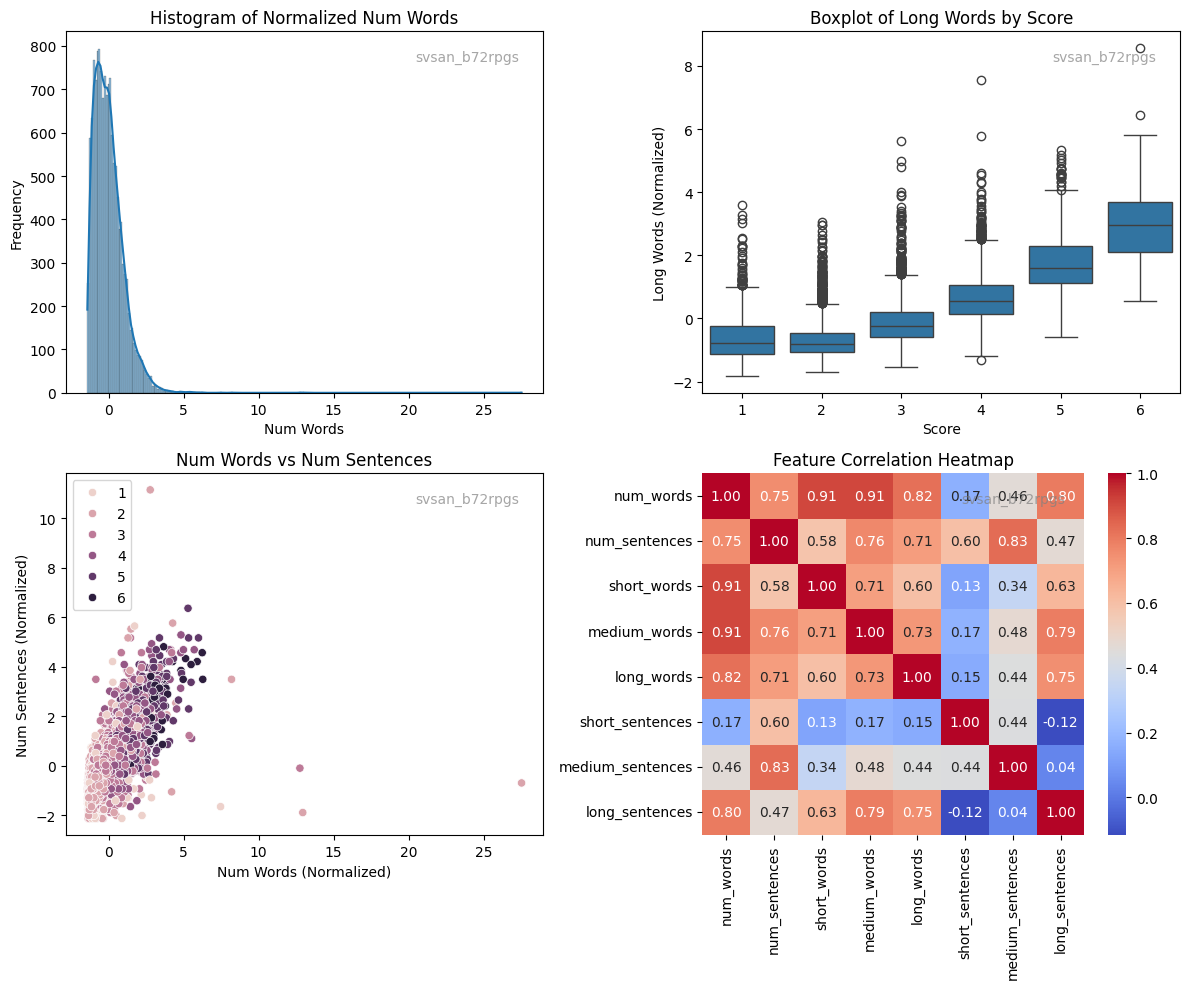

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(X_train_norm['num_words'], ax=axs[0, 0], kde=True)
axs[0, 0].set_title('Histogram of Normalized Num Words')
axs[0, 0].set_xlabel('Num Words')
axs[0, 0].set_ylabel('Frequency')

sns.boxplot(x=y_train, y=X_train_norm['pct_long_words'], ax=axs[0, 1])
axs[0, 1].set_title('Boxplot of Long Words by Score')
axs[0, 1].set_xlabel('Score')
axs[0, 1].set_ylabel('Percentage of Long Words (Normalized)')

sns.scatterplot(x=X_train_norm['num_words'], y=X_train_norm['num_sentences'], hue=y_train, ax=axs[1, 0])
axs[1, 0].set_title('Num Words vs Num Sentences')
axs[1, 0].set_xlabel('Num Words (Normalized)')
axs[1, 0].set_ylabel('Num Sentences (Normalized)')

corr = X_train_norm.corr()
sns.heatmap(corr, ax=axs[1, 1], annot=True, fmt=".2f", cmap='coolwarm')
axs[1, 1].set_title('Feature Correlation Heatmap')

for ax in axs.flatten():
    ax.text(0.95, 0.95, username, ha='right', va='top', transform=ax.transAxes, fontsize=10, color='gray', alpha=0.7)

plt.tight_layout()
plt.show()

### 1.3 K-Nearest Neighbors
#### 1.3.1 Implementation

In [8]:
class KNN:
    def __init__(self, k=5, distance="euclidean"):
        """Initialize the KNN essay scoring model."""
        self.k = k
        self.distance_metric = distance
        self.X_train = None
        self.y_train = None
        
    def fit(self, X_train, y_train):
        """Store the training feature vectors and scores."""
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)
        
    def _compute_distances(self, X):
        X = np.array(X)
        n_samples = X.shape[0]
        n_train = self.X_train.shape[0]
        dists = np.empty((n_samples, n_train))
        
        batch_size = 200
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            X_batch = X[i:end_idx]
            
            if self.distance_metric == "euclidean":
                dists[i:end_idx] = np.sqrt(((X_batch[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]) ** 2).sum(axis=2))
            elif self.distance_metric == "manhattan":
                dists[i:end_idx] = np.abs(X_batch[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]).sum(axis=2)
            elif self.distance_metric == "cosine":
                norm_X = np.linalg.norm(X_batch, axis=1)[:, np.newaxis]
                norm_train = np.linalg.norm(self.X_train, axis=1)[np.newaxis, :]
                norm_X[norm_X == 0] = 1
                norm_train[norm_train == 0] = 1
                dot = np.dot(X_batch, self.X_train.T)
                cos_sim = dot / (norm_X * norm_train)
                dists[i:end_idx] = 1 - cos_sim
            else:
                raise ValueError(f"Unknown metric {self.distance_metric}")
        return dists

    def predict(self, X):
        """Predict essay scores for the given feature vectors."""
        dists = self._compute_distances(X)
        preds = []
        for d in dists:
            k_indices = np.argsort(d)[:self.k]
            k_nearest_labels = self.y_train[k_indices]
            most_common = Counter(k_nearest_labels).most_common(1)
            preds.append(most_common[0][0])
        return np.array(preds)

#### 1.3.2 Hyperparameter Tuning

In [9]:
distances = ["euclidean", "manhattan", "cosine"]
ks = [1, 3, 5, 7, 9, 11, 15, 21]

results = []
best_acc = -1
best_config = None

for d in distances:
    knn_base = KNN(k=1, distance=d)
    knn_base.fit(X_train_norm, y_train)
    # Pre-compute distance matrix once per metric
    dists = knn_base._compute_distances(X_val_norm)
    
    for k in ks:
        preds = []
        for dist_row in dists:
            k_indices = np.argsort(dist_row)[:k]
            k_nearest_labels = knn_base.y_train[k_indices]
            most_common = Counter(k_nearest_labels).most_common(1)
            preds.append(most_common[0][0])
        preds = np.array(preds)
        
        acc = np.mean(preds == y_val)
        results.append({"Distance Metric": d.capitalize(), "K": k, "Validation Performance": acc})
        if acc > best_acc:
            best_acc = acc
            best_config = (d, k)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print(f"\nBest configuration: Distance = {best_config[0].capitalize()}, K = {best_config[1]} with validation accuracy = {best_acc:.4f}")

Distance Metric  K  Validation Performance
      Euclidean  1                0.446563
      Euclidean  3                0.481802
      Euclidean  5                0.516464
      Euclidean  7                0.528018
      Euclidean  9                0.533795
      Euclidean 11                0.555170
      Euclidean 15                0.554593
      Euclidean 21                0.547660
      Manhattan  1                0.441941
      Manhattan  3                0.487002
      Manhattan  5                0.512998
      Manhattan  7                0.515887
      Manhattan  9                0.531485
      Manhattan 11                0.547660
      Manhattan 15                0.552282
      Manhattan 21                0.555170
         Cosine  1                0.418833
         Cosine  3                0.458694
         Cosine  5                0.481802
         Cosine  7                0.501444
         Cosine  9                0.510687
         Cosine 11                0.522819
         Co

**Analysis**:
The choice of distance metric heavily influences how similarity is computed between essay features. Euclidean distance considers the absolute magnitude differences across all feature axes, which is appropriate for features that have been consistently normalized (Z-score). Manhattan distance can be more robust to outliers in specific features. Cosine distance looks at the angle between feature vectors rather than magnitude, which may or may not capture structural complexity of essays well. As K increases, the model's decision boundary becomes smoother, reducing variance but potentially increasing bias; typically an intermediate K yields the best validation performance.

### 1.4 Evaluation

In [ ]:
best_knn = KNN(k=best_config[1], distance=best_config[0])
best_knn.fit(X_train_norm, y_train)
y_pred = best_knn.predict(X_test_norm)

mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
y_mean = np.mean(y_test)
r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_mean)**2) if np.sum((y_test - y_mean)**2) != 0 else 0

num = np.sum((y_test - y_mean) * (y_pred - np.mean(y_pred)))
den = np.sqrt(np.sum((y_test - y_mean)**2) * np.sum((y_pred - np.mean(y_pred))**2))
pearson = num / den if den != 0 else 0

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R Score: {r2:.4f}")
print(f"Pearson Correlation Coefficient: {pearson:.4f}")

Mean Absolute Error (MAE): 0.5240
Root Mean Squared Error (RMSE): 0.8119
R Score: 0.3953
Pearson Correlation Coefficient: 0.6595
